# Clean CSV

Importation de la librairie

In [1]:
import pandas as pd

Chargement du fichier CSV

In [2]:
def find_file(filepath: str) -> pd.DataFrame:
    return pd.read_csv(filepath)

Supprimer les lignes vides ou doublons

In [3]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    df = df.dropna()
    df = df.drop_duplicates()
    return df

Chargement et nettoyage des CSV

In [4]:
def make_all():
    orders = clean(find_file('orders.csv'))
    order_products = clean(find_file('order_products.csv'))
    products = clean(find_file('products.csv'))
    aisles = clean(find_file('aisles.csv'))
    departments = clean(find_file('departments.csv'))
    return orders, order_products, products, aisles, departments

On Merge les fichier pour faire un seul DataFrame

In [ ]:
def merge(orders, order_products, products, aisles, departments):
     df = order_products.merge(orders, on='order_id')
     df = df.merge(products, on='product_id')
     df = df.merge(aisles, on='aisle_id')
     df = df.merge(departments, on='department_id')
     return df

On genere un autre fichier CSV apres le Merge

In [6]:
def final(df: pd.DataFrame, filepath: str = "cleaned.csv"):
    df.to_csv(filepath, index=False)


On construit le Main

In [ ]:
def main():
    orders, order_products, products, aisles, departments = make_all()
    df = merge(orders, order_products, products, aisles, departments)
    final(df)
    return df

On appelle le main pour executer toutes les FOnctions

In [ ]:
df = main()
df.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120.0,1.0,1.0,202279.0,3.0,5.0,9.0,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985.0,2.0,1.0,202279.0,3.0,5.0,9.0,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327.0,3.0,0.0,202279.0,3.0,5.0,9.0,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918.0,4.0,1.0,202279.0,3.0,5.0,9.0,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035.0,5.0,0.0,202279.0,3.0,5.0,9.0,8.0,Natural Sweetener,17,13,baking ingredients,pantry


# Question Graphique

- 1 : Quel est le Produit le Moin vendu ?

- 2 : Quelle est la proportion de Legume Bio vendu ?

- 3 : Quel est le Jour et l'heure de la semaine ou il y a le plus de Commandes ?

- 4 : Quel est le Jour de la semaine ou il y a le moin de vente ?

- 5 : Quel est le Département ou le taux de reachat est le plus élevé ?

- 6 : Quelle est la plus Haute fréquence des commandes par Client ?

- 7 : Quelle est la Taille moyenne du panier le Jeudi ?

- 8 : Quel est le département avec le plus de Commande ?

## Graphiques

Importation des librairies

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

Creation Variable Couleurs et Jours de la Semaines

In [10]:
BLUE = '#1f77b4'
LIGHT_BLUE = '#aec7e8'
JOURS = ['Dim', 'Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam']

Affchage des 10 produits les plus commandés

In [11]:
def graphique_top_produits():
    top = df['product_name'].value_counts().head(10)
    sns.barplot(x=top.values, y=top.index, color=BLUE)
    plt.title('Top 10 Produits Les Plus Vendus')
    plt.xlabel('Nombre de Commandes')
    plt.show()

Affiche la proportion de légumes frais bio vs non bio

In [12]:
def graphique_legumes_bio():
    legumes = df[df['aisle'] == 'fresh vegetables']
    bio = legumes['product_name'].str.contains('Organic', case=False).sum()
    plt.pie([bio, len(legumes) - bio], labels=['Bio', 'Non Bio'], autopct='%1.1f%%', colors=[BLUE, LIGHT_BLUE])
    plt.title('Proportion de Légumes Bio')
    plt.show()

Affiche une carte de chaleur des commandes par jour et heure

In [13]:
def graphique_carte_chaleur():
    heatmap = df.groupby(['order_dow', 'order_hour_of_day']).size().unstack()
    heatmap.index = JOURS
    sns.heatmap(heatmap, cmap='Blues')
    plt.title('Commandes par Jour et Heure')
    plt.xlabel('Heure de la Journée')
    plt.ylabel('Jour de la Semaine')
    plt.show()

Affiche le volume de ventes pour chaque jour de la semaine

In [14]:
def graphique_ventes_par_jour():
    df.groupby('order_dow')['product_id'].count().plot(marker='o', color=BLUE)
    plt.xticks(range(7), JOURS)
    plt.title('Ventes par Jour de la Semaine')
    plt.ylabel('Produits Vendus (en millions)')
    plt.show()

Affiche le taux de réachat moyen pour les 10 meilleurs départements

In [15]:
def graphique_taux_reachat_departements():
    taux = df.groupby('department')['reordered'].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=taux.values, y=taux.index, color=BLUE)
    plt.title('Taux de Réachat par Département (Top 10)')
    plt.xlabel('Taux (0 = jamais, 1 = toujours)')
    plt.show()

Affiche la distribution du nombre de commandes par client

In [16]:
def graphique_frequence_commandes():
    sns.histplot(df.groupby('user_id')['order_number'].max(), bins=20, color=BLUE)
    plt.title('Fréquence des Commandes par Client')
    plt.xlabel('Nombre de Commandes')
    plt.show()

Affiche la taille moyenne du panier pour chaque jour de la semaine

In [17]:
def graphique_taille_panier_jour():
    taille = df.groupby(['order_dow', 'order_id'])['product_id'].count().groupby('order_dow').mean()
    taille.plot(marker='o', color=BLUE)
    plt.xticks(range(7), JOURS)
    plt.title('Taille Moyenne du Panier par Jour')
    plt.ylabel('Produits Moyens par Commande')
    plt.show()

Affiche le nombre de commandes par département

In [18]:
def graphique_departements():
    dept = df.drop_duplicates(subset=['order_id', 'department']).groupby('department')['order_id'].count().sort_values(ascending=False)
    sns.barplot(x=dept.values, y=dept.index, color=BLUE)
    plt.title('Commandes par Département')
    plt.xlabel('Commandes (en millions)')
    plt.show()

Lancement de tous les graphiques

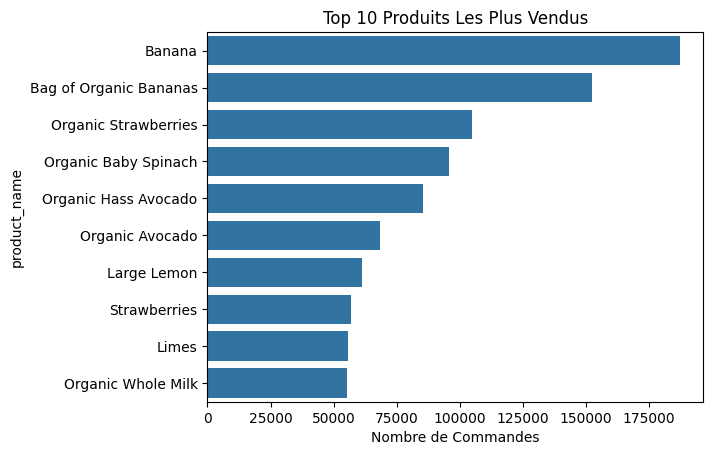

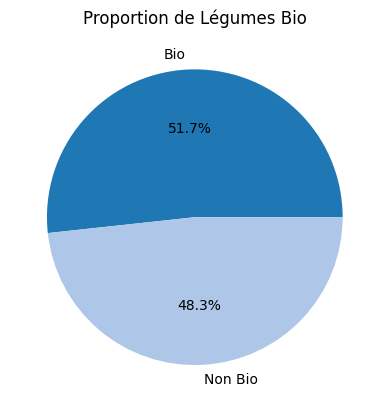

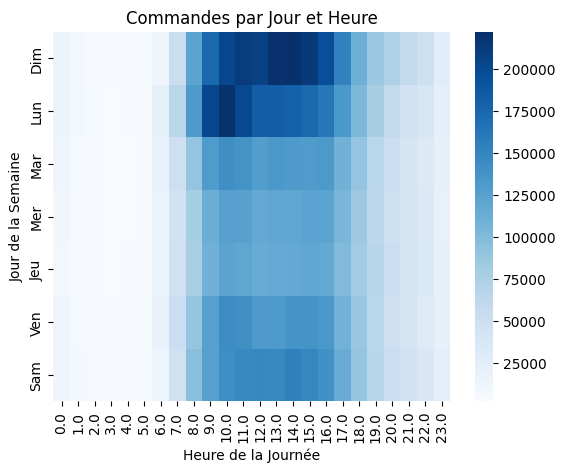

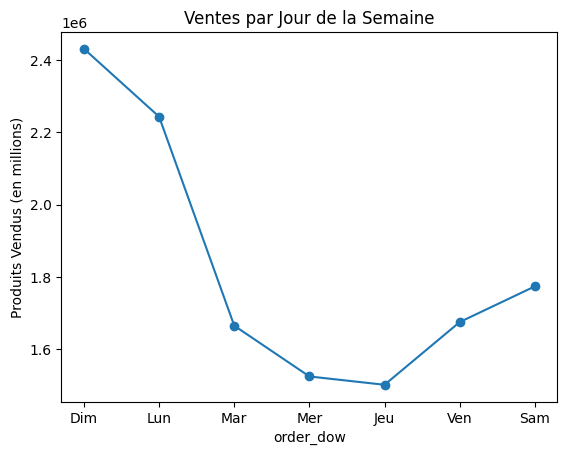

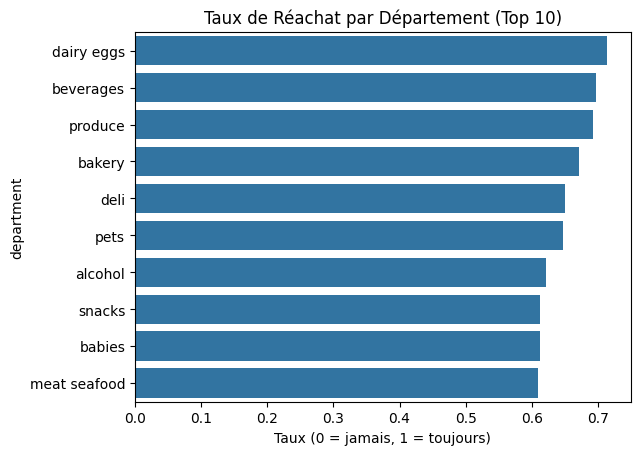

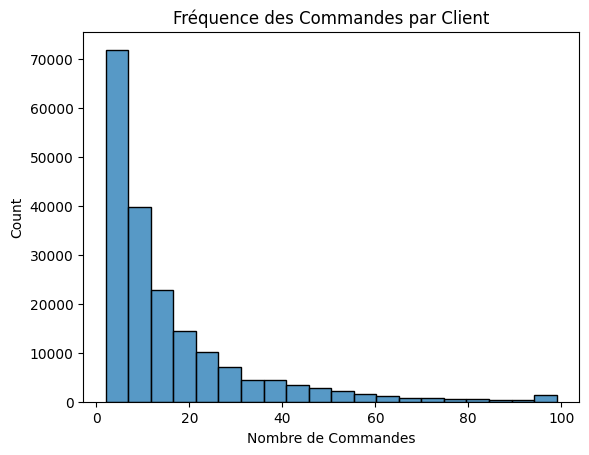

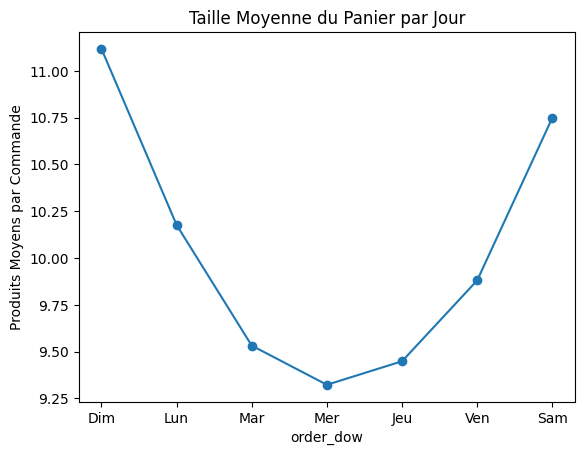

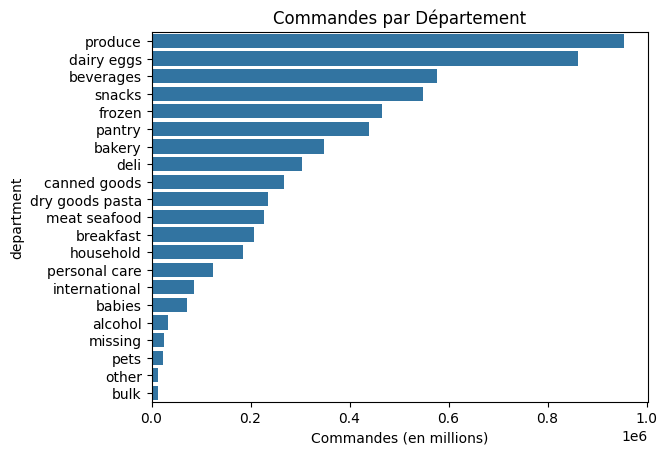

In [19]:
def tout_afficher():
    graphique_top_produits()
    graphique_legumes_bio()
    graphique_carte_chaleur()
    graphique_ventes_par_jour()
    graphique_taux_reachat_departements()
    graphique_frequence_commandes()
    graphique_taille_panier_jour()
    graphique_departements()

tout_afficher()

# IA

Importation des Librairies

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

Creation de deux nouvelles Features pour enrichir le LM

In [21]:

stats_produit = df.groupby('product_id')['reordered'].mean().reset_index()
stats_produit.columns = ['product_id', 'taux_reachat_produit']

stats_user = df.groupby('user_id')['order_number'].max().reset_index()
stats_user.columns = ['user_id', 'nb_commandes_user']

df_ml = df.merge(stats_produit, on='product_id')
df_ml = df_ml.merge(stats_user, on='user_id')

Creation de Fonction pour préparer les Datas

In [22]:
def prep_data(data):
    cols = ['order_dow', 'order_hour_of_day', 'days_since_prior_order',
            'add_to_cart_order', 'taux_reachat_produit', 'nb_commandes_user']
    X = data[cols].dropna()
    y = data.loc[X.index, 'reordered']
    return train_test_split(X, y, test_size=0.2, random_state=42)

ML 1 :

In [ ]:
def train_lr(X_train, y_train):
    model_lr = LogisticRegression(max_iter=1000)
    model_lr.fit(X_train, y_train)
    return model_lr

ML 2 :

In [24]:

def train_rf(X_train, X_test, y_train, y_test):
    model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
    model_rf.fit(X_train, y_train)
    return model_rf

Lancement de l'execution

In [25]:
X_train, X_test, y_train, y_test = prep_data(df_ml)
model_lr = train_lr(X_train, X_test, y_train, y_test)
model_rf = train_rf(X_train, X_test, y_train, y_test)

print(classification_report(y_test, model_lr.predict(X_test)))
print(classification_report(y_test, model_rf.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.64      0.42      0.50    948047
         1.0       0.72      0.86      0.78   1614289

    accuracy                           0.70   2562336
   macro avg       0.68      0.64      0.64   2562336
weighted avg       0.69      0.70      0.68   2562336

              precision    recall  f1-score   support

         0.0       0.61      0.48      0.54    948047
         1.0       0.73      0.82      0.77   1614289

    accuracy                           0.69   2562336
   macro avg       0.67      0.65      0.65   2562336
weighted avg       0.68      0.69      0.68   2562336

